In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
normal = pd.read_csv(r'C:\Users\EKR\Desktop\개인공부\2026 제조데이터분석 대회\data\raw\press_data_normal.csv')
outlier = pd.read_csv(r'C:\Users\EKR\Desktop\개인공부\2026 제조데이터분석 대회\data\raw\outlier_data.csv')
data=pd.concat([normal, outlier], ignore_index=True)
data.head()

,Unnamed: 0,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
0,0,2022-07-12 00:00:00.019,0.116967,-0.176403,192.338730,0
1,1,2022-07-12 00:00:00.119,0.030080,-0.210895,217.004330,0
2,2,2022-07-12 00:00:00.219,-0.045794,-0.029424,197.510620,0
3,3,2022-07-12 00:00:00.319,0.047519,0.258642,156.607170,0
4,4,2022-07-12 00:00:00.419,0.020351,0.173777,93.236934,0


In [3]:
cols = ["AI0_Vibration", "AI1_Vibration", "AI2_Current", "Equipment_state"]
corr = data[cols].corr()

In [4]:
corr

,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
AI0_Vibration,1.000000,0.140664,0.005451,0.012483
AI1_Vibration,0.140664,1.000000,0.002056,-0.010895
AI2_Current,0.005451,0.002056,1.000000,0.075780
Equipment_state,0.012483,-0.010895,0.075780,1.000000


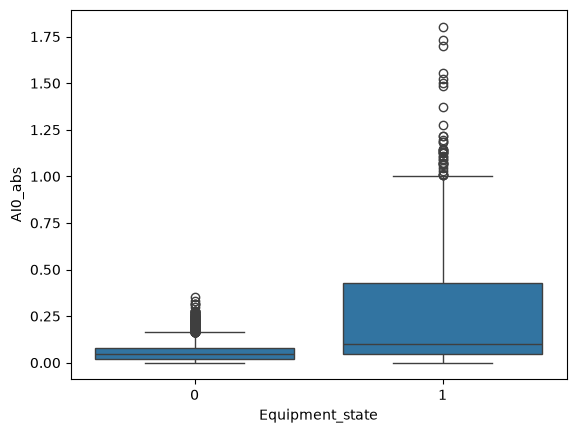

In [5]:
data["AI0_abs"] = data["AI0_Vibration"].abs()

sns.boxplot(
    data=data,
    x="Equipment_state",
    y="AI0_abs"
)
plt.show()

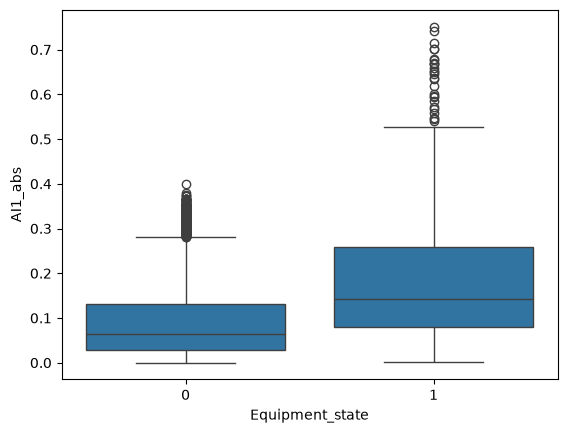

In [6]:
data["AI1_abs"] = data["AI1_Vibration"].abs()

sns.boxplot(
    data=data,
    x="Equipment_state",
    y="AI1_abs"
)

plt.show()

In [7]:
data["TimeStamp"]=pd.to_datetime(data["TimeStamp"])


data = data.sort_values("TimeStamp").reset_index(drop=True)

# 이전 샘플과 시간 차이
data["gap"] = data["TimeStamp"].diff().dt.total_seconds()

# 1초 이상 끊기면 새로운 burst
data["burst_id"] = (data["gap"].isna() | (data["gap"] > 1)).cumsum()

data[["TimeStamp", "gap", "burst_id"]].head(60)


,TimeStamp,gap,burst_id
0,2022-07-12 00:00:00.019,NaN,1
1,2022-07-12 00:00:00.119,0.100,1
2,2022-07-12 00:00:00.219,0.100,1
3,2022-07-12 00:00:00.319,0.100,1
4,2022-07-12 00:00:00.419,0.100,1
5,2022-07-12 00:00:00.519,0.100,1
6,2022-07-12 00:00:00.619,0.100,1
7,2022-07-12 00:00:00.719,0.100,1
8,2022-07-12 00:00:00.819,0.100,1
9,2022-07-12 00:00:00.919,0.100,1


In [8]:
# 바로 이전 행과의 시간 차이를 초 단위로 계산
data["gap"] = data["TimeStamp"].diff().dt.total_seconds()

# 바로 이전 행과 Equipment_state가 달라졌는지 확인
# 정상(0) → 이상(1)으로 바뀌는 지점도 새로운 burst로 처리하기 위함
data["state_change"] = data["Equipment_state"].ne(
    data["Equipment_state"].shift()
)

# 첫 번째 데이터이거나,
# 이전 샘플과 1초 이상 떨어졌거나,
# 정상/이상 상태가 바뀌면 새로운 burst로 판단
data["burst_id"] = (
    data["gap"].isna()
    | (data["gap"] > 1)
    | data["state_change"]
).cumsum()

# 총 burst 개수 확인
print("전체 burst 개수 :", data["burst_id"].nunique())

# 정상/이상별 burst 개수 확인
print(
    data.groupby("Equipment_state")["burst_id"].nunique()
)

# 각 burst에 몇 개의 샘플이 들어있는지 확인
data.groupby("burst_id").size().describe()

전체 burst 개수 : 620
Equipment_state
0    599
1     21
Name: burst_id, dtype: int64


count    620.000000
mean      33.225806
std       16.430811
min        1.000000
25%       19.750000
50%       37.000000
75%       50.000000
max       50.000000
dtype: float64

In [9]:
# 수치 계산용 numpy 불러오기
import numpy as np

# 첨도(kurtosis), 왜도(skewness) 계산용 scipy.stats 불러오기
from scipy import stats


# 하나의 burst 진동신호를 입력받아
# 여러 진동 특징(feature)을 계산하는 함수
def get_vibration_features(x):

    # pandas Series를 numpy 배열로 변환
    x = np.asarray(x)

    # 진동 신호의 평균값
    mean = np.mean(x)

    # 진동 신호 절댓값의 평균
    # 진동의 평균적인 크기를 나타냄
    mean_abs = np.mean(np.abs(x))

    # RMS 계산
    # 진동의 전체적인 에너지/세기를 나타내는 핵심 feature
    rms = np.sqrt(np.mean(x**2))

    # 표준편차
    # 진동값이 평균 주변에서 얼마나 크게 퍼져있는지 나타냄
    std = np.std(x, ddof=1)

    # 분산
    # 표준편차의 제곱
    variance = np.var(x, ddof=1)

    # 가장 큰 양의 진동값
    maximum = np.max(x)

    # 가장 작은 음의 진동값
    minimum = np.min(x)

    # 방향을 무시하고 가장 큰 순간 진동값
    max_abs = np.max(np.abs(x))

    # 최대값 - 최소값
    # 전체 진동 폭을 의미
    peak_to_peak = np.ptp(x)

    # 왜도
    # 진동 분포가 + 방향 또는 - 방향으로 치우쳐 있는지 확인
    skewness = stats.skew(x, bias=False)

    # 초과첨도
    # 순간적인 충격성 spike가 얼마나 강한지 확인
    # 정규분포라면 약 0
    kurtosis = stats.kurtosis(
        x,
        fisher=True,
        bias=False
    )

    # Crest Factor = 최대 진동 / RMS
    # 평소 진동에 비해 순간적인 peak가 얼마나 큰지 확인
    crest_factor = (
        max_abs / rms
        if rms != 0
        else np.nan
    )

    # Shape Factor = RMS / 평균 절댓값
    # 진동 파형의 형태 변화를 나타내는 지표
    shape_factor = (
        rms / mean_abs
        if mean_abs != 0
        else np.nan
    )

    # Impulse Factor = 최대 절댓값 / 평균 절댓값
    # 순간 충격이 얼마나 강한지 나타냄
    impulse_factor = (
        max_abs / mean_abs
        if mean_abs != 0
        else np.nan
    )

    # Clearance Factor 계산에 사용할 값
    sqrt_abs_mean = np.mean(np.sqrt(np.abs(x)))

    # Clearance Factor
    # 베어링이나 충격성 진동 분석에서 자주 사용하는 지표
    clearance_factor = (
        max_abs / (sqrt_abs_mean**2)
        if sqrt_abs_mean != 0
        else np.nan
    )

    # 계산한 모든 feature를 하나의 dictionary로 반환
    return {
        "Mean": mean,
        "MeanAbs": mean_abs,
        "RMS": rms,
        "STD": std,
        "Variance": variance,
        "Max": maximum,
        "Min": minimum,
        "MaxAbs": max_abs,
        "PeakToPeak": peak_to_peak,
        "Skewness": skewness,
        "Kurtosis": kurtosis,
        "CrestFactor": crest_factor,
        "ShapeFactor": shape_factor,
        "ImpulseFactor": impulse_factor,
        "ClearanceFactor": clearance_factor
    }

In [10]:
# 각 burst에서 계산한 feature를 저장할 빈 리스트 생성
rows = []


# burst_id별로 데이터를 하나씩 꺼내서 반복
for burst_id, group in data.groupby("burst_id"):

    # 현재 burst의 기본 정보 저장
    row = {
        "burst_id": burst_id,

        # 해당 burst가 정상(0)인지 이상(1)인지 저장
        "Equipment_state": group["Equipment_state"].iloc[0],

        # 해당 burst에 포함된 샘플 개수 저장
        "n_samples": len(group)
    }

    # AI0 진동센서의 모든 feature 계산
    ai0_features = get_vibration_features(
        group["AI0_Vibration"]
    )

    # AI0 feature 이름 앞에 AI0_를 붙여 저장
    # 예: RMS → AI0_RMS
    for name, value in ai0_features.items():
        row[f"AI0_{name}"] = value


    # AI1 진동센서의 모든 feature 계산
    ai1_features = get_vibration_features(
        group["AI1_Vibration"]
    )

    # AI1 feature 이름 앞에 AI1_를 붙여 저장
    # 예: RMS → AI1_RMS
    for name, value in ai1_features.items():
        row[f"AI1_{name}"] = value


    # 하나의 burst에서 만든 모든 feature를 리스트에 저장
    rows.append(row)


# 리스트를 pandas DataFrame으로 변환
# 이제 한 행 = 센서 샘플 하나가 아니라 burst 하나가 됨
featureData = pd.DataFrame(rows)


# 만들어진 feature 데이터 확인
featureData.head()

C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,burst_id,Equipment_state,n_samples,AI0_Mean,AI0_MeanAbs,AI0_RMS,AI0_STD,AI0_Variance,AI0_Max,AI0_Min,...,AI1_Max,AI1_Min,AI1_MaxAbs,AI1_PeakToPeak,AI1_Skewness,AI1_Kurtosis,AI1_CrestFactor,AI1_ShapeFactor,AI1_ImpulseFactor,AI1_ClearanceFactor
0,1,0,41,-6.957171e-03,0.055629,0.069009,0.069511,0.004832,0.191580,-0.128888,...,0.275627,-0.266900,0.275627,0.542527,0.184086,-1.358932,1.689117,1.121945,1.895097,2.079926
1,2,0,37,7.060946e-03,0.062671,0.073404,0.074072,0.005487,0.108161,-0.136729,...,0.244895,-0.180546,0.244895,0.425441,0.410586,-1.325153,1.849498,1.125586,2.081769,2.282815
2,3,0,24,-1.085608e-02,0.034435,0.040946,0.040329,0.001626,0.052827,-0.086432,...,0.085790,-0.093092,0.093092,0.178882,0.168964,-0.881725,1.871972,1.178782,2.206647,2.542627
3,4,0,10,2.786520e-02,0.045690,0.055487,0.050578,0.002558,0.108361,-0.051357,...,0.213480,-0.148429,0.213480,0.361909,0.106844,-1.524932,1.688143,1.145110,1.933109,2.188262
4,5,0,50,-4.000000e-08,0.033169,0.039326,0.039726,0.001578,0.078846,-0.083278,...,0.104080,-0.095669,0.104080,0.199749,0.051692,-0.390723,2.156202,1.238773,2.671045,3.143031


In [11]:
# 분석에서 비교할 AI0, AI1 진동 feature 이름 선택
feature_cols = [
    "AI0_RMS",
    "AI0_STD",
    "AI0_MaxAbs",
    "AI0_PeakToPeak",
    "AI0_Kurtosis",
    "AI0_CrestFactor",
    "AI0_ImpulseFactor",

    "AI1_RMS",
    "AI1_STD",
    "AI1_MaxAbs",
    "AI1_PeakToPeak",
    "AI1_Kurtosis",
    "AI1_CrestFactor",
    "AI1_ImpulseFactor"
]

# Equipment_state별로 각 feature의 중앙값 계산
# 0 = 정상, 1 = 이상
feature_summary = (
    featureData
    .groupby("Equipment_state")[feature_cols]
    .median()
    .T
)

# 결과 출력
feature_summary

Equipment_state,0,1
AI0_RMS,0.069417,0.391256
AI0_STD,0.069917,0.394928
AI0_MaxAbs,0.145581,1.006488
AI0_PeakToPeak,0.264134,1.659680
AI0_Kurtosis,-0.503394,0.720157
AI0_CrestFactor,2.141424,2.413797
AI0_ImpulseFactor,2.597829,3.275391
AI1_RMS,0.088976,0.253066
AI1_STD,0.088976,0.250760
AI1_MaxAbs,0.169869,0.645088


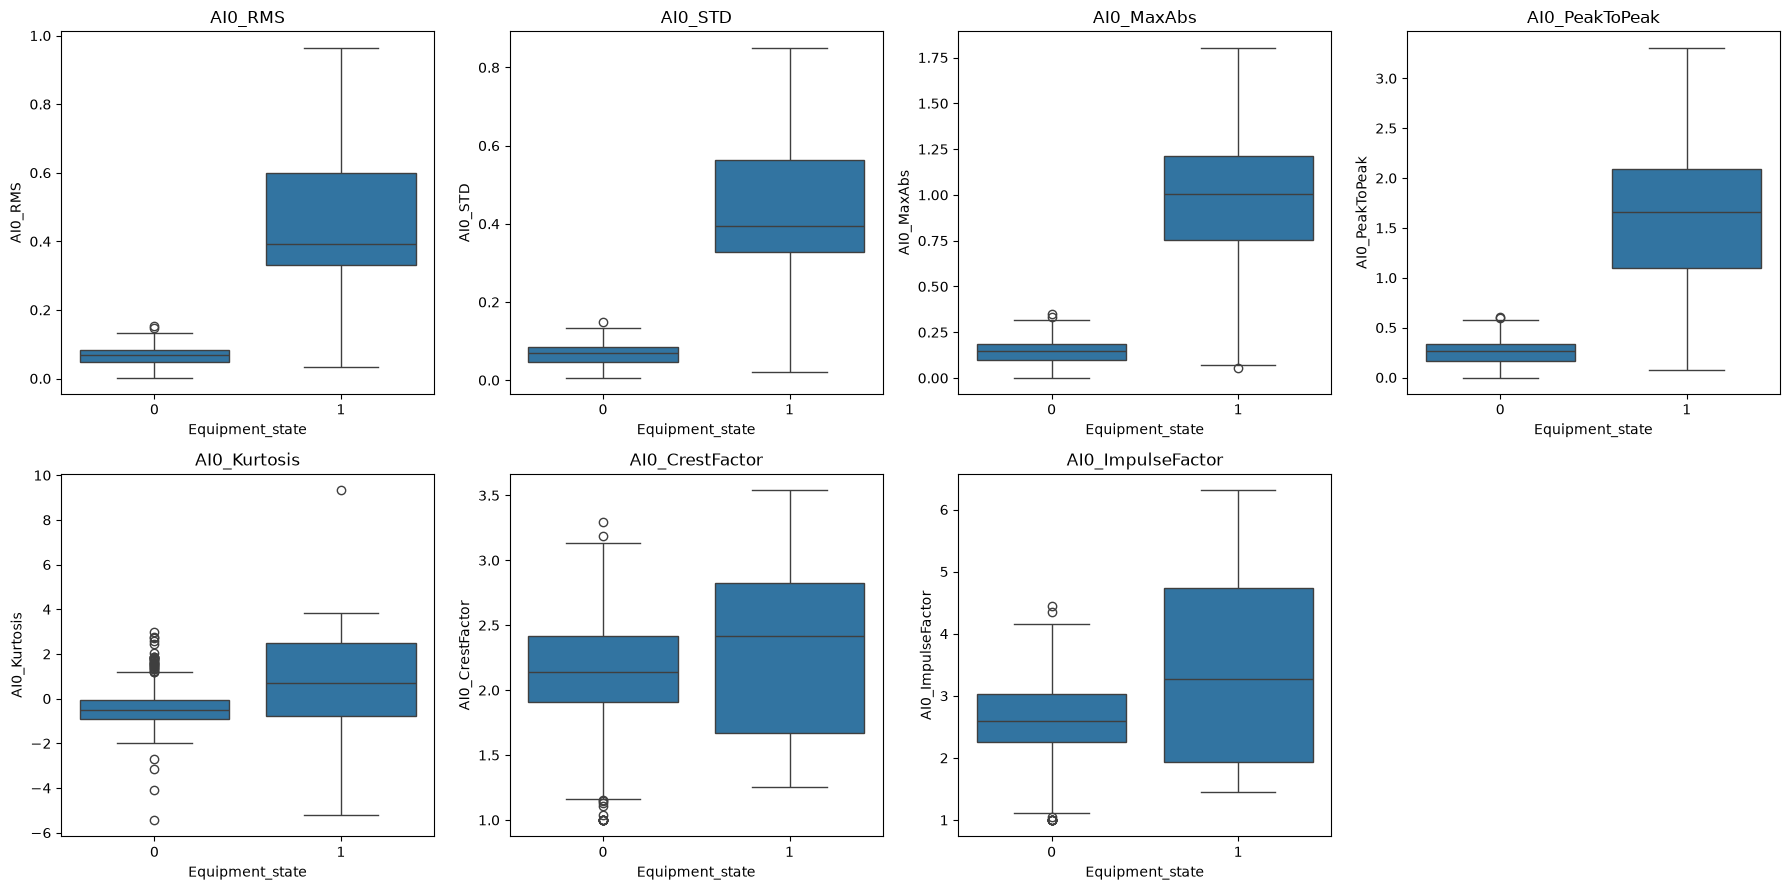

In [12]:
# 비교할 AI0 진동 feature 이름 지정
ai0_features = [
    "AI0_RMS",
    "AI0_STD",
    "AI0_MaxAbs",
    "AI0_PeakToPeak",
    "AI0_Kurtosis",
    "AI0_CrestFactor",
    "AI0_ImpulseFactor"
]

# 그래프를 2행 4열 형태로 생성
# feature가 7개라서 마지막 칸 하나는 비게 됨
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# 2차원 axes 배열을 1차원으로 펼침
# axes[0], axes[1]처럼 순서대로 사용하기 위함
axes = axes.flatten()

# AI0 feature를 하나씩 반복하면서 boxplot 생성
for i, feature in enumerate(ai0_features):

    # Equipment_state 0과 1에 따라
    # 각 feature의 burst별 분포를 비교
    sns.boxplot(
        data=featureData,
        x="Equipment_state",
        y=feature,
        ax=axes[i]
    )

    # 각 그래프 제목 설정
    axes[i].set_title(feature)

# 사용하지 않는 마지막 빈 그래프 제거
fig.delaxes(axes[-1])

# 그래프끼리 겹치지 않도록 자동 간격 조정
plt.tight_layout()

# 그래프 출력
plt.show()

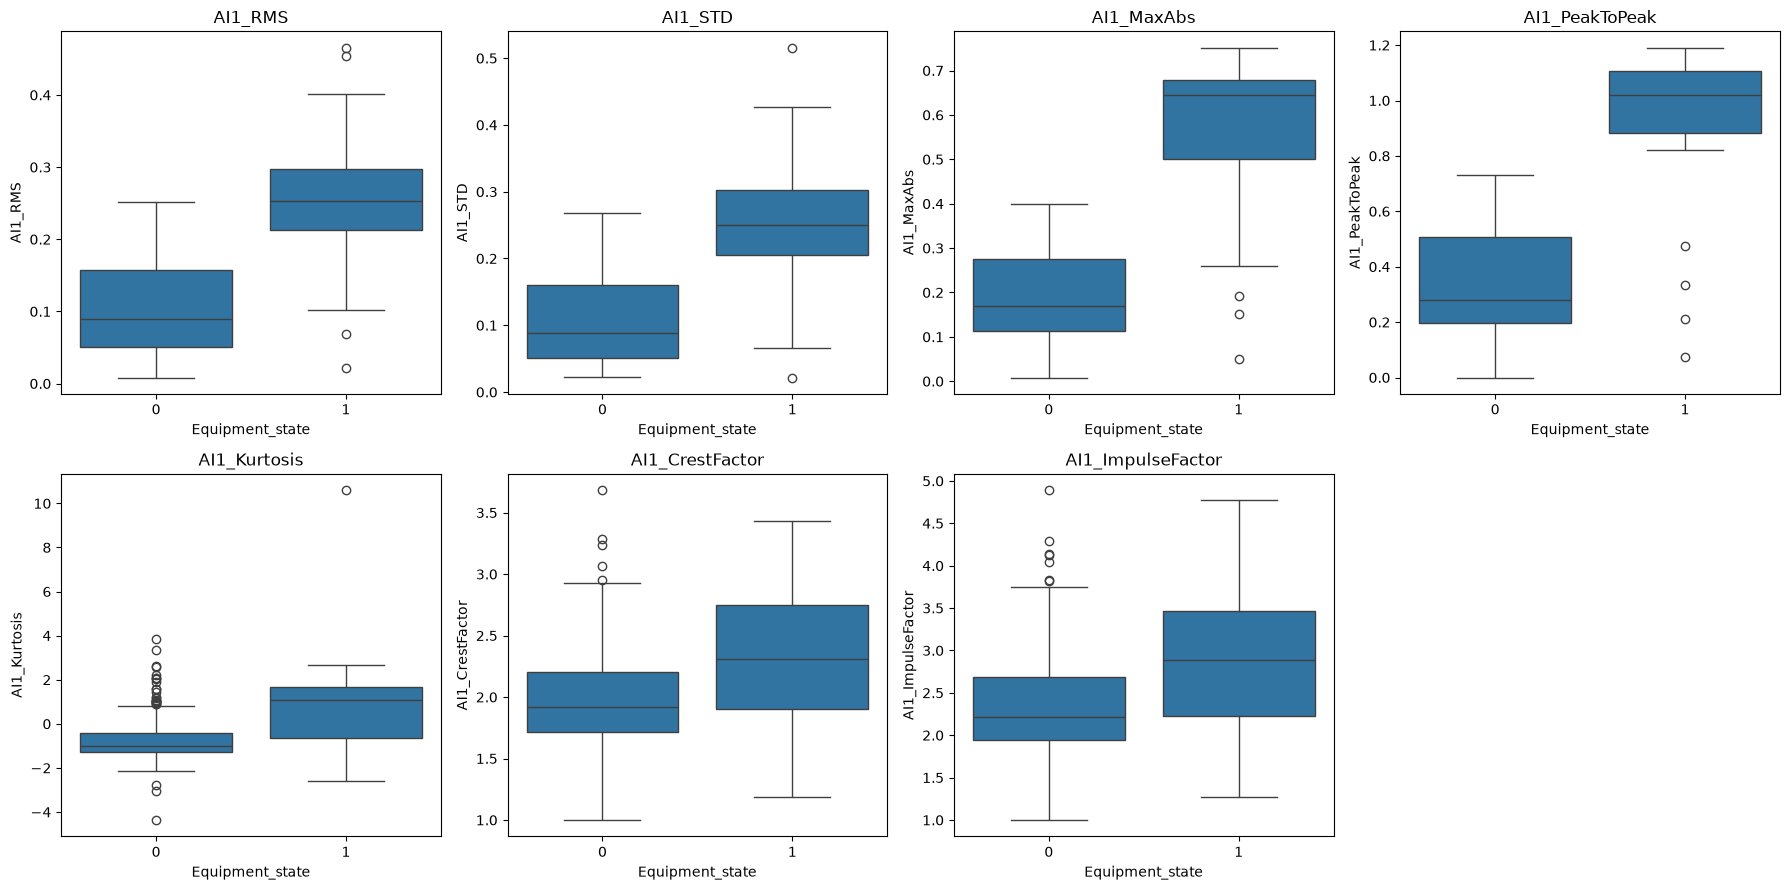

In [13]:
# AI1에서 비교할 진동 feature 목록 지정
ai1_features = [
    "AI1_RMS",
    "AI1_STD",
    "AI1_MaxAbs",
    "AI1_PeakToPeak",
    "AI1_Kurtosis",
    "AI1_CrestFactor",
    "AI1_ImpulseFactor"
]


# 2행 4열 형태의 그래프 공간 생성
# 총 feature가 7개라 마지막 한 칸은 비게 됨
fig, axes = plt.subplots(2, 4, figsize=(18, 9))


# axes를 1차원 배열로 변경
# axes[0], axes[1] ... 형태로 순서대로 사용하기 위함
axes = axes.flatten()


# AI1 feature를 하나씩 반복
for i, feature in enumerate(ai1_features):

    # 정상(0)과 이상(1)의 burst별 feature 분포를 boxplot으로 비교
    sns.boxplot(
        data=featureData,
        x="Equipment_state",
        y=feature,
        ax=axes[i]
    )

    # 각 그래프 제목을 feature 이름으로 설정
    axes[i].set_title(feature)


# feature가 7개라 사용하지 않는 마지막 그래프 칸 제거
fig.delaxes(axes[-1])


# 그래프끼리 제목이나 축이 겹치지 않도록 간격 자동 조정
plt.tight_layout()


# 그래프 출력
plt.show()

In [14]:
# 모델에 사용할 feature 선택
# 서로 비슷한 feature를 전부 넣기보다는 대표적인 feature부터 사용
features = [
    "AI0_RMS",
    "AI0_MaxAbs",
    "AI0_Kurtosis",
    "AI1_RMS",
    "AI1_PeakToPeak",
    "AI1_Kurtosis"
]


# 입력 데이터 X 생성
# 모델이 정상/이상을 판단할 때 사용할 센서 특징들
X = featureData[features]


# 정답 데이터 y 생성
# 0 = 정상, 1 = 이상
y = featureData["Equipment_state"]

In [15]:
# train/test 데이터 분리를 위한 함수 불러오기
from sklearn.model_selection import train_test_split


# 데이터를 학습용 80%, 테스트용 20%로 분리
# stratify=y를 사용하여 정상/이상 비율이 train과 test에서 비슷하게 유지되도록 함
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# feature들의 크기를 비슷한 범위로 맞추기 위한 StandardScaler 불러오기
from sklearn.preprocessing import StandardScaler


# scaler 생성
scaler = StandardScaler()


# 학습 데이터의 평균과 표준편차를 이용해서 scaling
X_train_scaled = scaler.fit_transform(X_train)


# 테스트 데이터는 학습 데이터에서 구한 기준으로만 scaling
# test 데이터 정보를 학습에 사용하면 안 되므로 transform만 사용
X_test_scaled = scaler.transform(X_test)

In [17]:
# 현재 모델에 넣으려고 선택한 feature들에서
# 각각 NaN이 몇 개 있는지 확인
featureData[features].isna().sum()

AI0_RMS           0
AI0_MaxAbs        0
AI0_Kurtosis      9
AI1_RMS           0
AI1_PeakToPeak    0
AI1_Kurtosis      9
dtype: int64

In [18]:
# AI0_Kurtosis 또는 AI1_Kurtosis가 NaN인 burst만 선택
kurtosis_nan = featureData[
    featureData["AI0_Kurtosis"].isna()
    | featureData["AI1_Kurtosis"].isna()
]

# 해당 burst의 번호, 정상/이상 상태, 샘플 개수 확인
kurtosis_nan[
    ["burst_id", "Equipment_state", "n_samples",
     "AI0_Kurtosis", "AI1_Kurtosis"]
]

,burst_id,Equipment_state,n_samples,AI0_Kurtosis,AI1_Kurtosis
40,41,0,1,NaN,NaN
143,144,0,1,NaN,NaN
291,292,0,1,NaN,NaN
314,315,0,1,NaN,NaN
370,371,0,1,NaN,NaN
382,383,0,1,NaN,NaN
394,395,0,1,NaN,NaN
416,417,0,1,NaN,NaN
530,531,0,1,NaN,NaN


In [19]:
# 각 burst에 들어있는 샘플 수의 분포 확인
featureData["n_samples"].describe()

count    620.000000
mean      33.225806
std       16.430811
min        1.000000
25%       19.750000
50%       37.000000
75%       50.000000
max       50.000000
Name: n_samples, dtype: float64

In [20]:
# 샘플이 10개 미만인 burst 개수 확인
(featureData["n_samples"] < 10).sum()

np.int64(73)

In [21]:
# 전체 burst 중 샘플이 10개 이상인 burst 개수 확인
(featureData["n_samples"] >= 10).sum()

np.int64(547)

In [22]:
# 샘플 수가 10개 미만인 짧은 burst에서
# 정상(0)과 이상(1)이 각각 몇 개인지 확인
featureData[
    featureData["n_samples"] < 10
]["Equipment_state"].value_counts()

Equipment_state
0    69
1     4
Name: count, dtype: int64

In [23]:
# 샘플 수가 10개 이상인 burst에서
# 정상(0)과 이상(1)이 각각 몇 개인지 확인
featureData[
    featureData["n_samples"] >= 10
]["Equipment_state"].value_counts()

Equipment_state
0    530
1     17
Name: count, dtype: int64

In [24]:
# TimeStamp가 실제 시간 자료형인지 확인하고 변환
data["TimeStamp"] = pd.to_datetime(data["TimeStamp"])


# 시간 순서대로 정렬
data = data.sort_values("TimeStamp").reset_index(drop=True)


# 바로 이전 샘플과의 시간 차이를 초 단위로 계산
data["gap"] = data["TimeStamp"].diff().dt.total_seconds()


# gap의 전체적인 분포를 숫자로 확인
# 평균, 표준편차, 최소값, 중앙값, 최대값 등을 보여줌
data["gap"].describe()

count     20599.000000
mean         22.876524
std        3250.003263
min           0.000000
25%           0.100000
50%           0.100000
75%           0.100000
max      466452.115000
Name: gap, dtype: float64

In [25]:
# gap 값의 분위수를 확인
# 대부분의 데이터가 어느 정도 시간 간격으로 측정되는지 확인하기 위함
data["gap"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.500    0.100000
0.750    0.100000
0.900    0.100000
0.950    0.100000
0.990    5.388080
0.995    6.545160
0.999    8.692804
Name: gap, dtype: float64

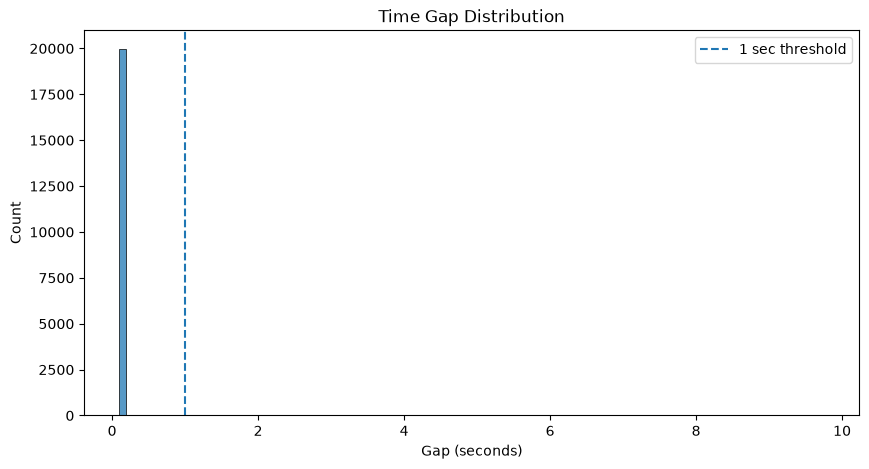

In [26]:
# 너무 큰 gap 몇 개 때문에 작은 값들이 안 보이는 것을 막기 위해
# 10초 이하의 gap만 우선 시각화
gap_plot = data.loc[
    (data["gap"] > 0) &
    (data["gap"] <= 10),
    "gap"
]


# gap 분포를 히스토그램으로 시각화
plt.figure(figsize=(10, 5))

sns.histplot(
    gap_plot,
    bins=100
)


# 현재 사용 중인 1초 기준을 빨간 세로선으로 표시
plt.axvline(
    1,
    linestyle="--",
    label="1 sec threshold"
)


# 그래프 제목과 축 이름 설정
plt.title("Time Gap Distribution")
plt.xlabel("Gap (seconds)")
plt.ylabel("Count")

plt.legend()
plt.show()

In [27]:
# gap을 시간 구간별로 나눠서 각각 몇 개가 있는지 확인
# 1초를 burst 분리 기준으로 사용하는 것이 적절한지 검증하기 위함

print(
    "0 ~ 0.2초 :",
    ((data["gap"] >= 0) & (data["gap"] <= 0.2)).sum()
)

print(
    "0.2 ~ 0.5초 :",
    ((data["gap"] > 0.2) & (data["gap"] <= 0.5)).sum()
)

print(
    "0.5 ~ 1초 :",
    ((data["gap"] > 0.5) & (data["gap"] <= 1)).sum()
)

print(
    "1 ~ 2초 :",
    ((data["gap"] > 1) & (data["gap"] <= 2)).sum()
)

print(
    "2 ~ 5초 :",
    ((data["gap"] > 2) & (data["gap"] <= 5)).sum()
)

print(
    "5초 이상 :",
    (data["gap"] > 5).sum()
)

0 ~ 0.2초 : 19980
0.2 ~ 0.5초 : 0
0.5 ~ 1초 : 0
1 ~ 2초 : 116
2 ~ 5초 : 267
5초 이상 : 236


In [28]:
# 샘플이 최소 4개 이상 있는 burst만 남김
# Kurtosis 같은 분포 기반 feature를 최소한 계산할 수 있는 burst만 사용하기 위함
featureData_clean = featureData[
    featureData["n_samples"] >= 4
].copy()


# 제거 후 정상(0), 이상(1) burst 개수 확인
featureData_clean["Equipment_state"].value_counts()

Equipment_state
0    575
1     20
Name: count, dtype: int64

In [29]:
# 현재 모델에 사용할 feature들 중
# NaN이 남아있는지 다시 확인
featureData_clean[features].isna().sum()

AI0_RMS           0
AI0_MaxAbs        0
AI0_Kurtosis      0
AI1_RMS           0
AI1_PeakToPeak    0
AI1_Kurtosis      0
dtype: int64

In [30]:
# 모델 입력값 X 생성
# 우리가 고른 진동 feature들만 사용
X = featureData_clean[features]


# 정답값 y 생성
# 0 = 정상
# 1 = 이상
y = featureData_clean["Equipment_state"]

In [31]:
# train/test 데이터 분리를 위한 함수 불러오기
from sklearn.model_selection import train_test_split


# 전체 데이터를 train 80%, test 20%로 분리
# stratify=y는 정상/이상 비율을 train과 test에서 비슷하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# train 데이터의 정상/이상 개수 확인
print("Train")
print(y_train.value_counts())


# test 데이터의 정상/이상 개수 확인
print("\nTest")
print(y_test.value_counts())

Train
Equipment_state
0    460
1     16
Name: count, dtype: int64

Test
Equipment_state
0    115
1      4
Name: count, dtype: int64


In [33]:
# feature들의 단위를 비슷한 스케일로 맞추기 위한 StandardScaler 불러오기
from sklearn.preprocessing import StandardScaler


# scaler 생성
scaler = StandardScaler()


# train 데이터의 평균과 표준편차를 기준으로
# train feature를 표준화
X_train_scaled = scaler.fit_transform(X_train)


# train에서 배운 평균과 표준편차를 그대로 사용해서
# test feature도 표준화
X_test_scaled = scaler.transform(X_test)

In [34]:
# Logistic Regression 분류 모델 불러오기
from sklearn.linear_model import LogisticRegression


# 클래스 불균형을 고려한 Logistic Regression 모델 생성
# 이상 데이터가 적기 때문에 class_weight="balanced" 사용
model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)


# train 데이터를 이용해서
# 각 feature의 weight와 bias 학습
model.fit(
    X_train_scaled,
    y_train
);

In [35]:
# test 데이터에 대해 정상/이상 예측
y_pred = model.predict(
    X_test_scaled
)

In [36]:
# 분류 모델 평가 함수 불러오기
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)


# 실제 정답과 예측값을 비교한 confusion matrix 출력
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# precision, recall, f1-score 출력
print(
    classification_report(
        y_test,
        y_pred
    )
)

[[114   1]
 [  0   4]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       115
           1       0.80      1.00      0.89         4

    accuracy                           0.99       119
   macro avg       0.90      1.00      0.94       119
weighted avg       0.99      0.99      0.99       119



In [37]:
# 여러 번 교차검증할 수 있도록 관련 함수 불러오기
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

# Scaling과 Logistic Regression을 하나로 묶기 위해 Pipeline 불러오기
from sklearn.pipeline import Pipeline

# StandardScaler와 Logistic Regression 불러오기
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# Scaling → Logistic Regression 순서로 실행되는 파이프라인 생성
# 각 fold의 train 데이터에서만 scaling 기준을 학습하므로 leakage를 막을 수 있음
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])


# 정상/이상 비율을 유지하면서 5개 fold로 나누고
# 이를 10번 반복해서 모델 성능의 안정성을 확인
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)


# 확인할 평가 지표 지정
scoring = [
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "roc_auc"
]


# 교차검증 실행
cv_result = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring
)


# 각 평가 지표의 평균 출력
print("Precision :", cv_result["test_precision"].mean())
print("Recall :", cv_result["test_recall"].mean())
print("F1 :", cv_result["test_f1"].mean())
print("Balanced Accuracy :", cv_result["test_balanced_accuracy"].mean())
print("ROC-AUC :", cv_result["test_roc_auc"].mean())


# 성능이 반복마다 얼마나 흔들리는지도 확인
print("\nRecall STD :", cv_result["test_recall"].std())
print("F1 STD :", cv_result["test_f1"].std())

Precision : 0.6982943722943722
Recall : 0.89
F1 : 0.757070707070707
Balanced Accuracy : 0.9362173913043479
ROC-AUC : 0.9432173913043479

Recall STD : 0.15132745950421556
F1 STD : 0.11973200106324633


In [38]:
# 각 feature에 대해 Logistic Regression이 학습한 weight 가져오기
# 이진 분류이므로 coef_[0]에 각 feature의 weight가 들어있음
weights = model.coef_[0]


# feature 이름과 weight를 보기 쉽게 DataFrame으로 정리
weight_df = pd.DataFrame({
    "Feature": features,
    "Weight": weights
})


# weight의 절댓값도 같이 계산
# 절댓값이 클수록 모델 판단에 더 강하게 사용된 feature라고 볼 수 있음
weight_df["Abs_Weight"] = weight_df["Weight"].abs()


# 영향력이 큰 feature부터 정렬
weight_df = weight_df.sort_values(
    "Abs_Weight",
    ascending=False
)


# 결과 확인
weight_df

,Feature,Weight,Abs_Weight
0,AI0_RMS,1.391838,1.391838
3,AI1_RMS,-0.826785,0.826785
5,AI1_Kurtosis,0.774276,0.774276
1,AI0_MaxAbs,0.636029,0.636029
4,AI1_PeakToPeak,-0.295754,0.295754
2,AI0_Kurtosis,0.029183,0.029183


In [64]:
# AI0_Kurtosis를 제거한 새로운 feature 목록
features_5 = [
    "AI0_RMS",
    "AI0_MaxAbs",
    "AI1_RMS",
    "AI1_PeakToPeak",
    "AI1_Kurtosis"
]


# 새로운 입력 데이터 생성
X_5 = featureData_clean[features_5]


# 같은 교차검증 조건으로 성능 비교
cv_result_5 = cross_validate(
    pipeline,
    X_5,
    y,
    cv=cv,
    scoring=scoring
)


# 기존 모델과 비교할 주요 성능 출력
print("Recall :", cv_result_5["test_recall"].mean())
print("F1 :", cv_result_5["test_f1"].mean())
print("Balanced Accuracy :", cv_result_5["test_balanced_accuracy"].mean())
print("ROC-AUC :", cv_result_5["test_roc_auc"].mean())
print("Precision :", cv_result_5["test_precision"].mean())

Recall : 0.9
F1 : 0.7764314574314574
Balanced Accuracy : 0.9418260869565219
ROC-AUC : 0.9478260869565218
Precision : 0.7254502164502165


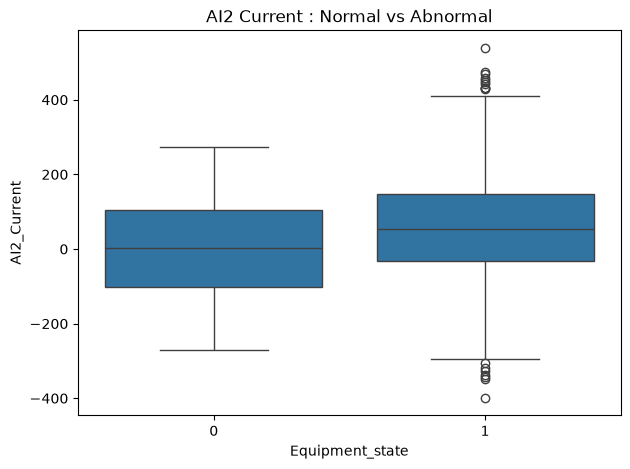

In [40]:
# 정상(0)과 이상(1) 상태에서
# 원시 전류값 AI2_Current의 분포를 boxplot으로 비교
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="Equipment_state",
    y="AI2_Current"
)

# 그래프 제목 설정
plt.title("AI2 Current : Normal vs Abnormal")

# 그래프 출력
plt.show()

In [41]:
# 각 burst에서 전류의 특징량을 계산할 함수 정의
def get_current_features(x):

    # pandas Series를 numpy 배열로 변환
    x = np.asarray(x)

    # 전류 평균값
    # 해당 burst에서 평균적으로 어느 정도 전류가 흘렀는지 나타냄
    mean = np.mean(x)

    # 전류 RMS
    # 해당 burst의 전체적인 전류 크기를 나타냄
    rms = np.sqrt(np.mean(x**2))

    # 전류 표준편차
    # burst 안에서 전류가 얼마나 크게 변했는지 나타냄
    std = np.std(x, ddof=1)

    # burst에서 가장 큰 전류값
    maximum = np.max(x)

    # burst에서 가장 작은 전류값
    minimum = np.min(x)

    # 최대 전류와 최소 전류의 차이
    # 전류의 전체 변동폭을 나타냄
    peak_to_peak = maximum - minimum

    # 계산한 전류 feature들을 반환
    return {
        "Mean": mean,
        "RMS": rms,
        "STD": std,
        "Max": maximum,
        "Min": minimum,
        "PeakToPeak": peak_to_peak
    }

In [42]:
# burst별 전류 feature를 저장할 빈 리스트 생성
current_rows = []


# burst_id별로 데이터를 하나씩 꺼냄
for burst_id, group in data.groupby("burst_id"):

    # 해당 burst의 기본 정보 저장
    row = {
        "burst_id": burst_id,

        # 정상(0) / 이상(1) 상태 저장
        "Equipment_state": group["Equipment_state"].iloc[0],

        # 해당 burst의 샘플 개수 저장
        "n_samples": len(group)
    }

    # 현재 burst의 전류 feature 계산
    current_features = get_current_features(
        group["AI2_Current"]
    )

    # feature 이름 앞에 Current_를 붙여 저장
    # 예: RMS → Current_RMS
    for name, value in current_features.items():
        row[f"Current_{name}"] = value

    # 하나의 burst 결과를 리스트에 추가
    current_rows.append(row)


# 리스트를 DataFrame으로 변환
currentFeatureData = pd.DataFrame(current_rows)


# 앞부분 확인
currentFeatureData.head()

C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,burst_id,Equipment_state,n_samples,Current_Mean,Current_RMS,Current_STD,Current_Max,Current_Min,Current_PeakToPeak
0,1,0,41,19.085886,149.170481,149.782344,219.93151,-219.31734,439.24885
1,2,0,37,-5.676624,139.745235,141.555912,217.53814,-216.01834,433.55648
2,3,0,24,-6.102717,80.082896,81.567430,110.77358,-109.87891,220.65249
3,4,0,10,15.061905,154.819184,162.419616,204.71635,-211.22303,415.93938
4,5,0,50,0.442267,81.545626,82.372310,111.29559,-110.31391,221.60950


In [43]:
# burst별 전류 feature를 저장할 빈 리스트 생성
current_rows = []


# burst_id별로 데이터를 하나씩 가져옴
for burst_id, group in data.groupby("burst_id"):

    # 해당 burst의 샘플 수 계산
    n_samples = len(group)

    # 샘플이 4개 미만인 burst는
    # 통계 feature의 신뢰도가 낮으므로 분석에서 제외
    if n_samples < 4:
        continue


    # 현재 burst의 기본 정보 저장
    row = {
        "burst_id": burst_id,

        # 정상(0) / 이상(1) 상태 저장
        "Equipment_state": group["Equipment_state"].iloc[0],

        # burst의 샘플 개수 저장
        "n_samples": n_samples
    }


    # 현재 burst의 전류 feature 계산
    current_features_temp = get_current_features(
        group["AI2_Current"]
    )


    # 계산한 feature 이름 앞에 Current_를 붙여 저장
    for name, value in current_features_temp.items():
        row[f"Current_{name}"] = value


    # 완성된 한 burst의 feature를 리스트에 저장
    current_rows.append(row)


# burst별 전류 feature를 DataFrame으로 변환
currentFeatureData_clean = pd.DataFrame(current_rows)


# 정상/이상 burst 개수 확인
currentFeatureData_clean["Equipment_state"].value_counts()

Equipment_state
0    575
1     20
Name: count, dtype: int64

In [44]:
# 전류 feature에서 비교할 항목 지정
current_features = [
    "Current_Mean",
    "Current_RMS",
    "Current_STD",
    "Current_Max",
    "Current_Min",
    "Current_PeakToPeak"
]


# 정상(0), 이상(1)별로 각 전류 feature의 중앙값 계산
# 평균보다 중앙값을 쓰면 극단값의 영향을 덜 받음
current_summary = (
    currentFeatureData_clean
    .groupby("Equipment_state")[current_features]
    .median()
    .T
)


# 결과 출력
current_summary

Equipment_state,0,1
Current_Mean,0.588455,22.944953
Current_RMS,100.220172,134.867747
Current_STD,96.598829,87.741092
Current_Max,145.059960,161.528605
Current_Min,-137.799400,-120.401400
Current_PeakToPeak,278.932600,319.480931


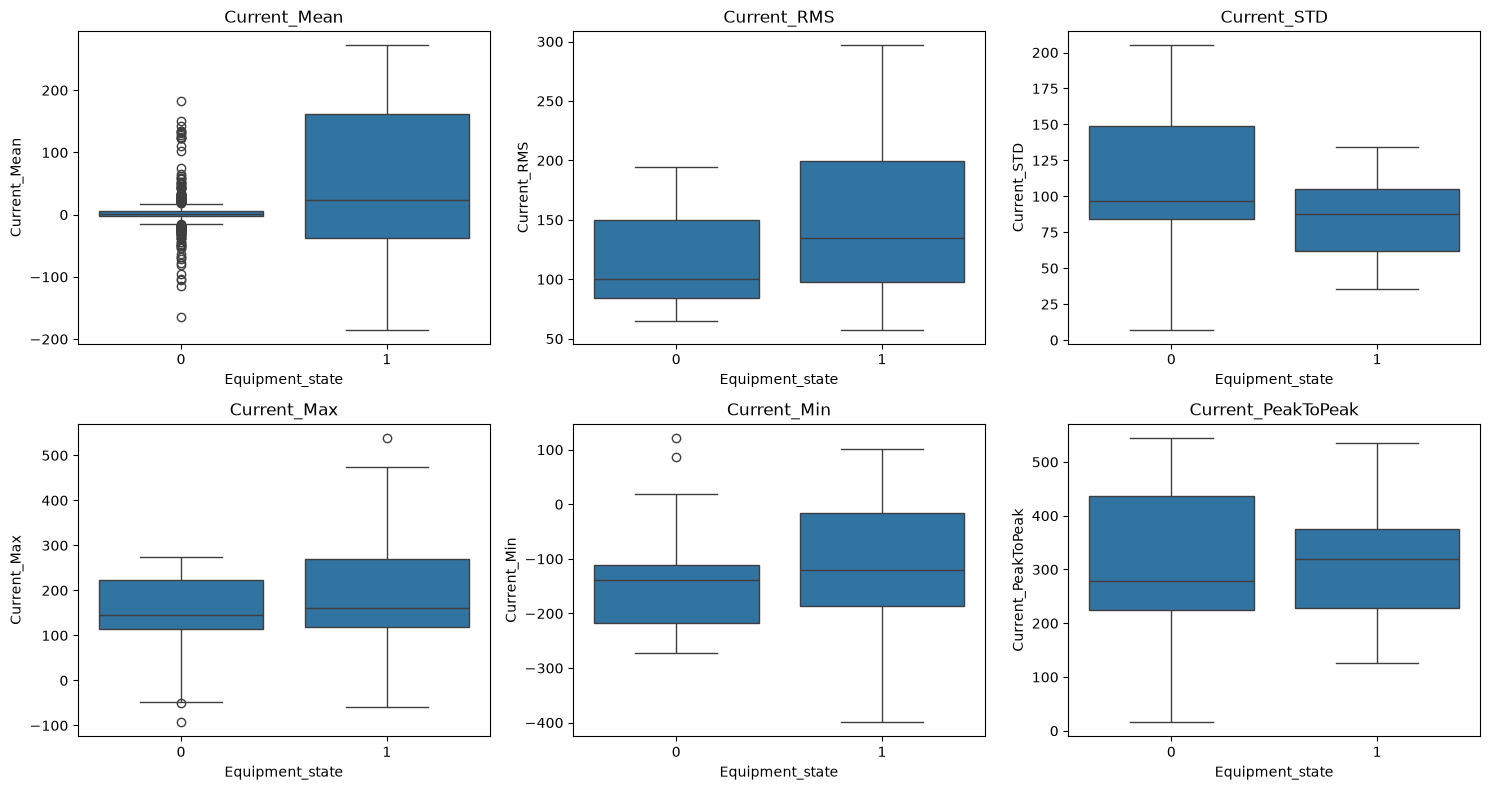

In [45]:
# 전류 feature 6개를 한 화면에서 보기 위해 2행 3열 그래프 생성
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)


# axes를 1차원으로 펼쳐서 순서대로 사용
axes = axes.flatten()


# 각 전류 feature에 대해 정상/이상 boxplot 생성
for i, feature in enumerate(current_features):

    # Equipment_state 0과 1의 burst별 feature 분포 비교
    sns.boxplot(
        data=currentFeatureData_clean,
        x="Equipment_state",
        y=feature,
        ax=axes[i]
    )

    # 각 그래프 제목 설정
    axes[i].set_title(feature)


# 그래프 간격 자동 조정
plt.tight_layout()


# 그래프 출력
plt.show()

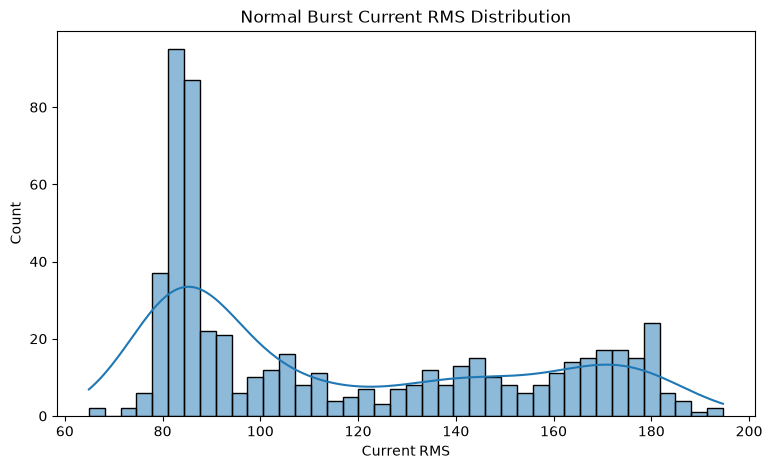

In [46]:
# 정상 burst만 선택
normal_current = currentFeatureData_clean[
    currentFeatureData_clean["Equipment_state"] == 0
].copy()


# 정상 burst들의 Current_RMS 분포를 히스토그램으로 확인
# 봉우리가 두 개로 나뉘는지 확인하기 위함
plt.figure(figsize=(9, 5))

sns.histplot(
    data=normal_current,
    x="Current_RMS",
    bins=40,
    kde=True
)


# 그래프 제목과 축 이름 설정
plt.title("Normal Burst Current RMS Distribution")
plt.xlabel("Current RMS")
plt.ylabel("Count")


# 그래프 출력
plt.show()

In [47]:
# K-Means 클러스터링 모델 불러오기
from sklearn.cluster import KMeans


# 정상 burst의 Current_RMS만 입력 데이터로 사용
# KMeans는 2차원 입력을 요구하므로 [["Current_RMS"]] 형태로 선택
X_current_normal = normal_current[["Current_RMS"]]


# 정상 운전 상태가 2개 존재한다고 가정하고
# K-Means를 이용해 두 군집으로 분리
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)


# 각 정상 burst가 어느 cluster에 속하는지 계산
normal_current["Current_cluster"] = kmeans.fit_predict(
    X_current_normal
)


# 두 cluster의 Current_RMS 중심값 확인
print("Cluster centers:")
print(kmeans.cluster_centers_)


# 각 cluster에 몇 개의 burst가 들어갔는지 확인
print("\nCluster counts:")
print(
    normal_current["Current_cluster"].value_counts()
)

Cluster centers:
[[159.71581896]
 [ 89.66487974]]

Cluster counts:
Current_cluster
1    353
0    222
Name: count, dtype: int64


C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [48]:
# 현재 K=2 클러스터가 얼마나 잘 분리되어 있는지 평가
# 1에 가까울수록 군집이 잘 분리되어 있다는 뜻
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_current_normal,
    normal_current["Current_cluster"]
)

print("Silhouette score :", score)

Silhouette score : 0.7624650130632213


In [49]:
# 클러스터 개수를 2, 3, 4로 바꾸면서
# 어떤 K가 현재 정상 Current RMS 분포에 가장 잘 맞는지 비교
for k in [2, 3, 4]:

    # K개의 클러스터를 갖는 K-Means 모델 생성
    model_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # 각 정상 burst를 클러스터로 분류
    labels = model_k.fit_predict(
        X_current_normal
    )

    # 클러스터 분리 정도 계산
    score = silhouette_score(
        X_current_normal,
        labels
    )

    # 결과 출력
    print(f"K={k}  Silhouette={score:.3f}")

C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=2  Silhouette=0.762


C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=3  Silhouette=0.719
K=4  Silhouette=0.701


C:\Users\EKR\miniconda3-pbe\envs\ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [50]:
# 정상 burst의 Current_cluster 정보를
# 진동 feature가 있는 featureData_clean에 붙이기
normal_with_cluster = featureData_clean[
    featureData_clean["Equipment_state"] == 0
].merge(
    normal_current[
        ["burst_id", "Current_cluster", "Current_RMS"]
    ],
    on="burst_id",
    how="inner"
)


# 두 운전모드에서 주요 진동 feature의 중앙값 비교
cluster_vibration_summary = (
    normal_with_cluster
    .groupby("Current_cluster")[
        [
            "AI0_RMS",
            "AI0_MaxAbs",
            "AI1_RMS",
            "AI1_PeakToPeak",
            "AI1_Kurtosis"
        ]
    ]
    .median()
    .T
)


# 결과 확인
cluster_vibration_summary

Current_cluster,0,1
AI0_RMS,0.082677,0.056195
AI0_MaxAbs,0.191503,0.114521
AI1_RMS,0.173773,0.053848
AI1_PeakToPeak,0.546234,0.218676
AI1_Kurtosis,-1.274820,-0.535482


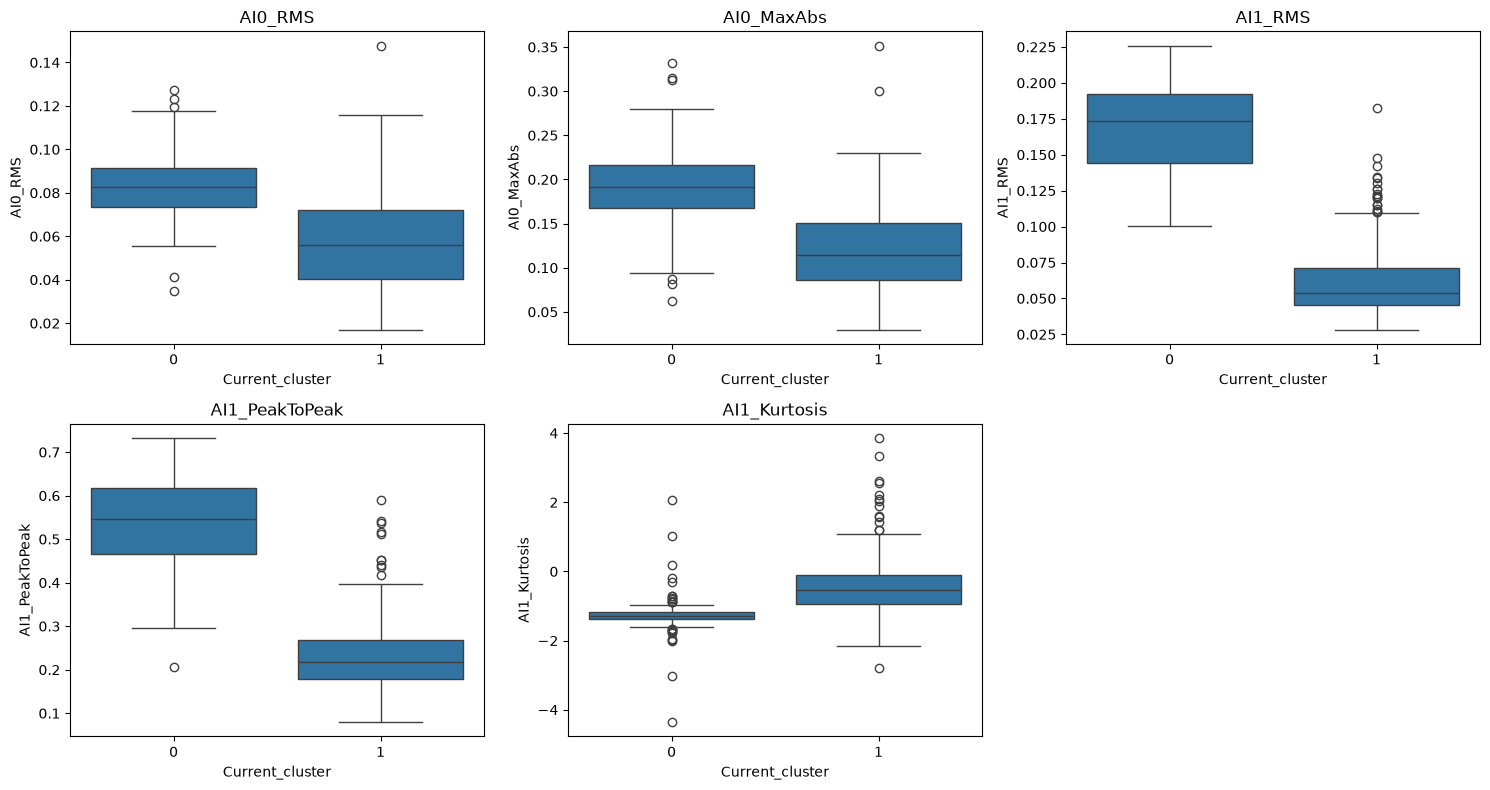

In [51]:
# 비교할 주요 진동 feature 목록
cluster_features = [
    "AI0_RMS",
    "AI0_MaxAbs",
    "AI1_RMS",
    "AI1_PeakToPeak",
    "AI1_Kurtosis"
]


# 2행 3열 그래프 생성
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)


# axes를 1차원으로 변환
axes = axes.flatten()


# 각 feature를 Current_cluster별로 비교
for i, feature in enumerate(cluster_features):

    sns.boxplot(
        data=normal_with_cluster,
        x="Current_cluster",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)


# 남는 마지막 그래프 제거
fig.delaxes(axes[-1])


# 그래프 간격 조정
plt.tight_layout()


# 그래프 출력
plt.show()

In [52]:
# 각 burst의 AI0와 AI1 진동 신호 사이 Pearson 상관계수를 계산
# 한 burst당 correlation 값 하나가 만들어짐
burst_corr = (
    data[data["burst_id"].isin(featureData_clean["burst_id"])]
    .groupby("burst_id")
    .apply(
        lambda group: group["AI0_Vibration"].corr(
            group["AI1_Vibration"]
        )
    )
    .rename("AI0_AI1_Corr")
    .reset_index()
)


# 계산 결과 확인
burst_corr.head()

,burst_id,AI0_AI1_Corr
0,1,0.258693
1,2,0.276604
2,3,0.132513
3,4,0.233594
4,5,0.119689


In [53]:
# 기존 burst feature 데이터에
# 새로 계산한 AI0-AI1 correlation feature를 burst_id 기준으로 결합
featureData_corr = featureData_clean.merge(
    burst_corr,
    on="burst_id",
    how="left"
)


# correlation 계산 과정에서 NaN이 생겼는지 확인
featureData_corr["AI0_AI1_Corr"].isna().sum()

np.int64(0)

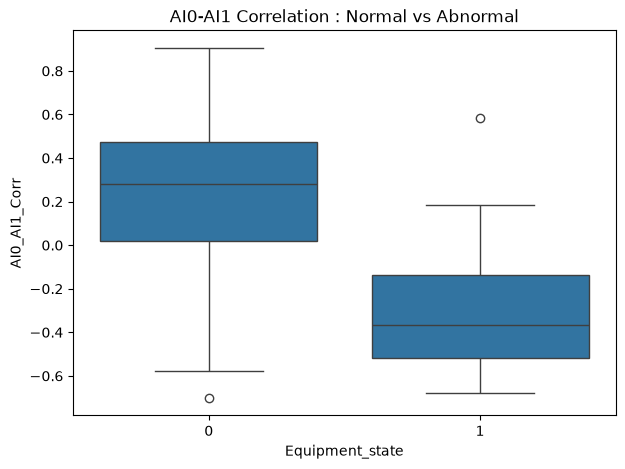

In [54]:
# 정상(0)과 이상(1)에서
# AI0-AI1 correlation 분포가 어떻게 달라지는지 boxplot으로 확인
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=featureData_corr,
    x="Equipment_state",
    y="AI0_AI1_Corr"
)

# 그래프 제목 설정
plt.title("AI0-AI1 Correlation : Normal vs Abnormal")

# 그래프 출력
plt.show()

In [55]:
# Current 자기상관을 계산할 때
# 1.6초 = 10 Hz × 1.6초 = 16 sample이므로 lag=16 사용
lag = 16


# burst마다 Current lag=16 자기상관을 계산해서 저장할 리스트
current_autocorr_rows = []


# 각 burst를 하나씩 가져와서 반복
for burst_id, group in data.groupby("burst_id"):

    # lag=16 자기상관을 계산하려면
    # 최소한 16개보다 충분히 많은 sample이 필요하므로
    # 여기서는 30개 이상인 burst만 사용
    if len(group) < 30:
        continue

    # 해당 burst의 Current 신호에서
    # 16 sample 전 값과 현재 값의 자기상관 계산
    autocorr_16 = group["AI2_Current"].autocorr(lag=lag)

    # burst 번호, 정상/이상 상태, 자기상관값 저장
    current_autocorr_rows.append({
        "burst_id": burst_id,
        "Equipment_state": group["Equipment_state"].iloc[0],
        "Current_Autocorr_1.6s": autocorr_16
    })


# 결과를 DataFrame으로 변환
current_autocorr = pd.DataFrame(current_autocorr_rows)


# 정상/이상별 자기상관 중앙값 확인
current_autocorr.groupby(
    "Equipment_state"
)["Current_Autocorr_1.6s"].median()

Equipment_state
0    0.967638
1   -0.145756
Name: Current_Autocorr_1.6s, dtype: float64

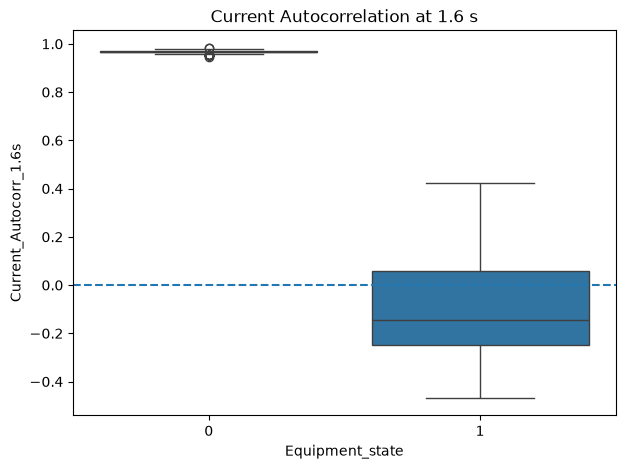

In [56]:
# 정상과 이상에서
# 1.6초 자기상관이 실제로 얼마나 다른지 boxplot으로 비교
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=current_autocorr,
    x="Equipment_state",
    y="Current_Autocorr_1.6s"
)

# 자기상관 0 기준선 표시
plt.axhline(
    0,
    linestyle="--"
)

# 그래프 제목 설정
plt.title("Current Autocorrelation at 1.6 s")

# 그래프 출력
plt.show()

In [57]:
# 10 Hz 데이터에서
# lag 1~30 = 0.1초~3.0초 범위의 자기상관을 확인
lags = range(1, 31)


# 정상/이상별 autocorrelation 결과를 저장할 리스트
acf_rows = []


# 각 burst별로 반복
for burst_id, group in data.groupby("burst_id"):

    # 최대 lag 30까지 보기 위해
    # 충분히 긴 burst만 사용
    if len(group) < 40:
        continue

    # 정상/이상 상태 저장
    state = group["Equipment_state"].iloc[0]

    # lag를 하나씩 변경하면서 autocorrelation 계산
    for lag in lags:

        # Current의 해당 lag 자기상관 계산
        ac = group["AI2_Current"].autocorr(lag=lag)

        # 결과 저장
        acf_rows.append({
            "burst_id": burst_id,
            "Equipment_state": state,
            "lag": lag,
            "lag_sec": lag / 10,
            "autocorr": ac
        })


# DataFrame으로 변환
acf_data = pd.DataFrame(acf_rows)


# 각 lag에서 정상/이상 burst들의 자기상관 중앙값 계산
acf_summary = (
    acf_data
    .groupby(["Equipment_state", "lag_sec"])["autocorr"]
    .median()
    .reset_index()
)

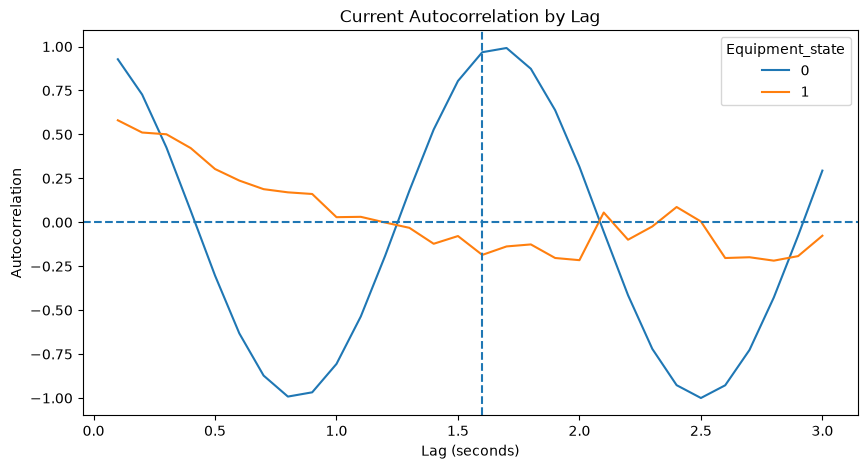

In [58]:
# 정상과 이상의 Current 자기상관 패턴을 시간 지연별로 비교
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=acf_summary,
    x="lag_sec",
    y="autocorr",
    hue="Equipment_state"
)

# Claude가 언급한 1.6초 위치 표시
plt.axvline(
    1.6,
    linestyle="--",
    label="1.6 sec"
)

# 자기상관 0 기준선 표시
plt.axhline(
    0,
    linestyle="--"
)

# 그래프 제목 설정
plt.title("Current Autocorrelation by Lag")

plt.xlabel("Lag (seconds)")
plt.ylabel("Autocorrelation")

plt.show()

In [59]:
# Current 자기상관을 계산할 때
# 1.6초 = 10 Hz × 1.6초 = 16 sample이므로 lag=16 사용
lag = 16


# burst마다 Current lag=16 자기상관을 계산해서 저장할 리스트
current_autocorr_rows = []


# 각 burst를 하나씩 가져와서 반복
for burst_id, group in data.groupby("burst_id"):

    # lag=16 자기상관을 계산하려면
    # 최소한 16개보다 충분히 많은 sample이 필요하므로
    # 여기서는 30개 이상인 burst만 사용
    if len(group) < 30:
        continue

    # 해당 burst의 Current 신호에서
    # 16 sample 전 값과 현재 값의 자기상관 계산
    autocorr_16 = group["AI2_Current"].autocorr(lag=lag)

    # burst 번호, 정상/이상 상태, 자기상관값 저장
    current_autocorr_rows.append({
        "burst_id": burst_id,
        "Equipment_state": group["Equipment_state"].iloc[0],
        "Current_Autocorr_1.6s": autocorr_16
    })


# 결과를 DataFrame으로 변환
current_autocorr = pd.DataFrame(current_autocorr_rows)


# 정상/이상별 자기상관 중앙값 확인
current_autocorr.groupby(
    "Equipment_state"
)["Current_Autocorr_1.6s"].median()

Equipment_state
0    0.967638
1   -0.145756
Name: Current_Autocorr_1.6s, dtype: float64

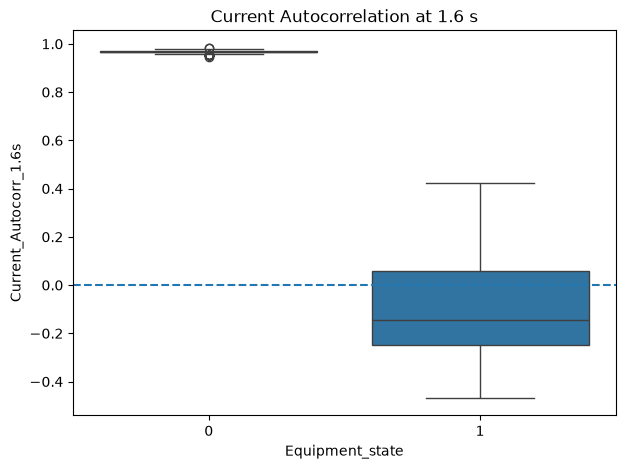

In [60]:
# 정상과 이상에서
# 1.6초 자기상관이 실제로 얼마나 다른지 boxplot으로 비교
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=current_autocorr,
    x="Equipment_state",
    y="Current_Autocorr_1.6s"
)

# 자기상관 0 기준선 표시
plt.axhline(
    0,
    linestyle="--"
)

# 그래프 제목 설정
plt.title("Current Autocorrelation at 1.6 s")

# 그래프 출력
plt.show()

In [61]:
# lag=16 자기상관 계산에 실제 사용된 burst들의 길이를
# 정상/이상 상태별로 요약해서 확인
current_autocorr.merge(
    featureData[["burst_id", "n_samples"]],
    on="burst_id",
    how="left"
).groupby("Equipment_state")["n_samples"].describe()

,count,mean,std,min,25%,50%,75%,max
Equipment_state,,,,,,,,
0,360.0,45.369444,6.381524,30.0,40.0,50.0,50.0,50.0
1,10.0,44.600000,6.979335,31.0,40.5,48.5,50.0,50.0


In [62]:
# 1.6초 자기상관 계산에 실제 사용된
# 정상/이상 burst 개수 확인
current_autocorr["Equipment_state"].value_counts()

Equipment_state
0    360
1     10
Name: count, dtype: int64

In [63]:
# Autoencoder에 사용할 burst-level feature 지정
# 기존 Logistic Regression과 같은 feature를 사용해서 모델 방식 자체의 차이를 비교
features_ae = [
    "AI0_RMS",
    "AI0_MaxAbs",
    "AI1_RMS",
    "AI1_PeakToPeak",
    "AI1_Kurtosis",
    "AI0_AI1_Corr"
]


# 필요한 feature와 장비 상태만 가져오기
ae_data = featureData_corr[
    features_ae + ["Equipment_state", "burst_id"]
].dropna().copy()


# 정상/이상 burst 개수 확인
print(ae_data["Equipment_state"].value_counts())

Equipment_state
0    575
1     20
Name: count, dtype: int64
